## Settings

In [1]:
import os, sys
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

sys.path.append(os.path.abspath('../../..'))
load_dotenv(os.path.join('../../..', '.env'))

os.environ['GRAPHRAG_API_KEY'] = os.environ.get('GEMINI_API_KEY', '')

QUESTION_TYPE = "multihop"          # local | global | multihop | comparative | negative
N_LIBROS      = 10
MAX_Q         = None
SHUFFLE       = False
RESULTS_DIR   = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)
DOMINIO = "cs"

In [2]:
DB_RAG = "../../../chroma_db_eval_traditional"
DB_RAGPlusPlus = "../../../chroma_db_RAGPlusPlus"
DB_LightRAG = "../../../lightrag_eval"
DB_PropertyRAG = ""
DB_MSGraphRAG = "../../../ms_graphrag_workspace"

In [3]:
from src.evaluation.experiment import run_local_experiment

PATH_PREGUNTAS = "./qa/multihopQA.json"
PATH_RESULTADOS = "./results/"

/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/instructor/providers/gemini/client.py:6: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## Traditional RAG

In [4]:
from src.baselines.traditional_rag import TraditionalRAG

rag = TraditionalRAG(persist_directory=DB_RAG)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando índice existente desde ../../../chroma_db_eval_traditional...


In [5]:
resultado = await run_local_experiment(
    rag_type="traditional",
    rag_object=rag,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_MultiHop_01"
)


🔍 Evaluando TRADITIONAL | Test_MultiHop_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Both the SQL Server book and the Linux Kernel Networking book deal wit...
  [2/20] The Spark MLlib book and the Modern Optimization With R book both cove...
  [3/20] The VBA book teaches automation of Microsoft Office applications. If a...
  [4/20] The Java book and the programming languages theory book both touch on ...
  [5/20] Joe Celko emphasizes naming conventions in SQL. If the Linux kernel na...
  [6/20] Both the regular expressions book and the programming languages theory...
  [7/20] The statistics book covers probability distributions and the Spark boo...
  [8/20] The SQL Server book and the statistics book both deal with aggregation...
  [9/20] Both the Linux Kernel and the Spark book operate on distributed or par...
  [10/20] The regular expressions book and the SQL book both provide pattern-mat...
  [11/20] The Java book covers object-oriented in

## RAG++

In [6]:
from src.baselines.advanced_rag import AdvancedRAG

rag_advanced = AdvancedRAG(persist_directory=DB_RAGPlusPlus)
rag_advanced.load_existing_index() 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Docs recuperados de Chroma: 11824
   _all_docs construidos: 11824


In [7]:
resultado = await run_local_experiment(
    rag_type="advanced",
    rag_object=rag_advanced,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_MultiHop_01"
)


🔍 Evaluando ADVANCED | Test_MultiHop_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Both the SQL Server book and the Linux Kernel Networking book deal wit...
  [2/20] The Spark MLlib book and the Modern Optimization With R book both cove...
  [3/20] The VBA book teaches automation of Microsoft Office applications. If a...
  [4/20] The Java book and the programming languages theory book both touch on ...
  [5/20] Joe Celko emphasizes naming conventions in SQL. If the Linux kernel na...
  [6/20] Both the regular expressions book and the programming languages theory...
  [7/20] The statistics book covers probability distributions and the Spark boo...
  [8/20] The SQL Server book and the statistics book both deal with aggregation...
  [9/20] Both the Linux Kernel and the Spark book operate on distributed or par...
  [10/20] The regular expressions book and the SQL book both provide pattern-mat...
  [11/20] The Java book covers object-oriented inher

## LightRAG

In [8]:
from src.baselines.lightrag_rag import build_lightrag

rag_light, tracker = await build_lightrag(
    workspace_dir=DB_LightRAG,
    clean=False,
)

INFO: [] Loaded graph from ../../../lightrag_eval/graph_chunk_entity_relation.graphml with 54773 nodes, 72142 edges
INFO:nano-vectordb:Load (54773, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_entities.json'} 54773 data
INFO:nano-vectordb:Load (72142, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_relationships.json'} 72142 data
INFO:nano-vectordb:Load (3712, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_chunks.json'} 3712 data
INFO: [] Process 6765 KV load full_docs with 10 records
INFO: [] Process 6765 KV load text_chunks with 3712 records
INFO: [] Process 6765 KV load full_entities with 10 records
INFO: [] Process 6765 KV load full_relations with 10 records
INFO: [] Process 6765 KV load entity_chunks with 54773 records
INFO: [] Process 6765 KV load relatio

✅ LightRAG inicializado en: ../../../lightrag_eval
   max_async=12 | max_retries=10 | modelo=gemini-2.5-flash-lite
   chunk_size=600 | gleaning=0


In [9]:
resultado = await run_local_experiment(
    rag_type="lightrag",
    rag_object=rag_light,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_MultiHop_01"
)

INFO: LLM func: 12 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)



🔍 Evaluando LIGHTRAG | Test_MultiHop_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Both the SQL Server book and the Linux Kernel Networking book deal wit...


INFO:  == LLM cache == saving: hybrid:keywords:daf7a6d891646433b748f22757d5831c
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)
INFO: Query nodes: primary data unit, row, network packet (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 300 relations
INFO: Query edges: data at scale, SQL Server, Linux Kernel Networking (top_k:40, cosine:0.2)
INFO: Global query: 48 entites, 40 relations
INFO: Raw search results: 88 entities, 340 relations, 0 vector chunks
INFO: After truncation: 67 entities, 217 relations
INFO: Selecting 167 from 290 entity-related chunks by vector similarity
INFO: Find 46 additional chunks in 40 relations (deduplicated 56)
INFO: Selecting 46 from 46 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 213 -> 213 (deduplicated 0)
INFO: Final context: 67 entities, 217 relations, 20 chunks
INFO: Final chunks S+F/O: E6/1 R1/1 E3/2 R1/2 E7/3 R1/3 E1/4 R1/4 E5/5 R2/5 E4/6 R1/6 E3/7 R1/7 E2/8 R1

  [2/20] The Spark MLlib book and the Modern Optimization With R book both cove...


INFO:  == LLM cache == saving: hybrid:keywords:5533c66fb35257229262cde4ad4583a4
INFO: Query nodes: Spark MLlib book, Modern Optimization With R book, Specific algorithm (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 377 relations
INFO: Query edges: Metaheuristic techniques, Population-based optimization (top_k:40, cosine:0.2)
INFO: Global query: 46 entites, 40 relations
INFO: Raw search results: 86 entities, 417 relations, 0 vector chunks
INFO: After truncation: 69 entities, 216 relations
INFO: Selecting 172 from 252 entity-related chunks by vector similarity
INFO: Find 7 additional chunks in 7 relations (deduplicated 79)
INFO: Selecting 7 from 7 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 179 -> 179 (deduplicated 0)
INFO: Final context: 69 entities, 216 relations, 20 chunks
INFO: Final chunks S+F/O: E6/1 R1/1 E10/2 R1/2 E4/3 R1/3 E6/4 R1/4 E3/5 R5/5 E7/6 R4/6 E4/7 R1/7 E1/8 E10/9 E1/10 E3/11 E6/12 E3/13
INFO:  == LLM cache == saving: hybrid:que

...


📊 Calculando métricas RAGAS...
  RAGAS [1/20] Both the SQL Server book and the Linux Kernel Netw...
  RAGAS [2/20] The Spark MLlib book and the Modern Optimization W...
  RAGAS [3/20] The VBA book teaches automation of Microsoft Offic...
  RAGAS [4/20] The Java book and the programming languages theory...
  RAGAS [5/20] Joe Celko emphasizes naming conventions in SQL. If...
  RAGAS [6/20] Both the regular expressions book and the programm...
  RAGAS [7/20] The statistics book covers probability distributio...
  RAGAS [8/20] The SQL Server book and the statistics book both d...
  RAGAS [9/20] Both the Linux Kernel and the Spark book operate o...


INFO:openai._base_client:Retrying request to /chat/completions in 0.422220 seconds


  RAGAS [10/20] The regular expressions book and the SQL book both...
  RAGAS [11/20] The Java book covers object-oriented inheritance a...
  RAGAS [12/20] The optimization book uses the R function optim() ...
  RAGAS [13/20] Dowek's programming languages book discusses type ...
  RAGAS [14/20] The statistics book covers Chebyshev's inequality ...
  RAGAS [15/20] Both Celko's SQL book and the SQL Server book disc...


INFO:openai._base_client:Retrying request to /chat/completions in 0.443227 seconds


  RAGAS [16/20] The regular expressions book covers greedy vs lazy...
  RAGAS [17/20] The Linux Kernel book discusses the sk_buff struct...
  RAGAS [18/20] The VBA book covers error handling and the Java bo...
  RAGAS [19/20] The optimization book covers the Traveling Salesma...
  RAGAS [20/20] Both the Spark book and the Linux Kernel book deal...

  💰 Tokens RAGAS:
     Total  : 169,274  (prompt: 151,963 | completion: 17,311)
     TPM    : 48,879 tokens/min
     RPM    : 40 requests/min  (140 requests en 3.46 min)
💾 Guardado en: ./results/lightrag_Test_MultiHop_01_2026-05-02.json


## Property RAG

## MS_GraphRAG

In [10]:
from src.baselines.msgraphrag_rag import MSGraphRAG

ms_graph = MSGraphRAG(workspace_dir=DB_MSGraphRAG)
ms_graph.load()

📂 Cargando índice MS-GraphRAG...
   ✅ Entidades    : 31,159
   ✅ Relaciones   : 42,358
   ✅ Comunidades  : 4,612
   ✅ Reports      : 4,603
   ✅ Text units   : 1,867


In [12]:
resultado = await run_local_experiment(
    rag_type="msgraphrag_local",
    rag_object=ms_graph,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_MultiHop_01"
)


🔍 Evaluando MSGRAPHRAG_LOCAL | Test_MultiHop_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Both the SQL Server book and the Linux Kernel Networking book deal wit...


11:34:47 - LiteLLM:INFO: utils.py:1307 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
11:34:47 - LiteLLM:INFO: utils.py:3427 - 
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini
INFO:LiteLLM:
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini


  [2/20] The Spark MLlib book and the Modern Optimization With R book both cove...


11:34:50 - LiteLLM:INFO: utils.py:1307 - Wrapper: Completed Call, calling success_handler
INFO:LiteLLM:Wrapper: Completed Call, calling success_handler
11:34:51 - LiteLLM:INFO: utils.py:3427 - 
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini
INFO:LiteLLM:
LiteLLM completion() model= gemini-2.5-flash-lite; provider = gemini


  [3/20] The VBA book teaches automation of Microsoft Office applications. If a...


...


📊 Calculando métricas RAGAS...
  RAGAS [1/19] Both the SQL Server book and the Linux Kernel Netw...
  RAGAS [2/19] The Spark MLlib book and the Modern Optimization W...
  RAGAS [3/19] The VBA book teaches automation of Microsoft Offic...
  RAGAS [4/19] The Java book and the programming languages theory...
  RAGAS [5/19] Joe Celko emphasizes naming conventions in SQL. If...
  RAGAS [6/19] Both the regular expressions book and the programm...


INFO:openai._base_client:Retrying request to /chat/completions in 0.376413 seconds


  RAGAS [7/19] The statistics book covers probability distributio...
  RAGAS [8/19] The SQL Server book and the statistics book both d...
  RAGAS [9/19] Both the Linux Kernel and the Spark book operate o...
  RAGAS [10/19] The regular expressions book and the SQL book both...
  RAGAS [11/19] The Java book covers object-oriented inheritance a...
  RAGAS [12/19] The optimization book uses the R function optim() ...
  RAGAS [13/19] Dowek's programming languages book discusses type ...


INFO:openai._base_client:Retrying request to /chat/completions in 0.412474 seconds


  RAGAS [14/19] The statistics book covers Chebyshev's inequality ...
  RAGAS [15/19] Both Celko's SQL book and the SQL Server book disc...
  RAGAS [16/19] The regular expressions book covers greedy vs lazy...
  RAGAS [17/19] The Linux Kernel book discusses the sk_buff struct...
  RAGAS [18/19] The VBA book covers error handling and the Java bo...
  RAGAS [19/19] Both the Spark book and the Linux Kernel book deal...

  💰 Tokens RAGAS:
     Total  : 591,159  (prompt: 556,130 | completion: 35,029)
     TPM    : 89,929 tokens/min
     RPM    : 30 requests/min  (194 requests en 6.57 min)
💾 Guardado en: ./results/msgraphrag_local_Test_MultiHop_01_2026-05-02.json


## Plots

✅ 4 RAGs cargados: ['traditional', 'advanced', 'lightrag', 'msgraphrag_local']


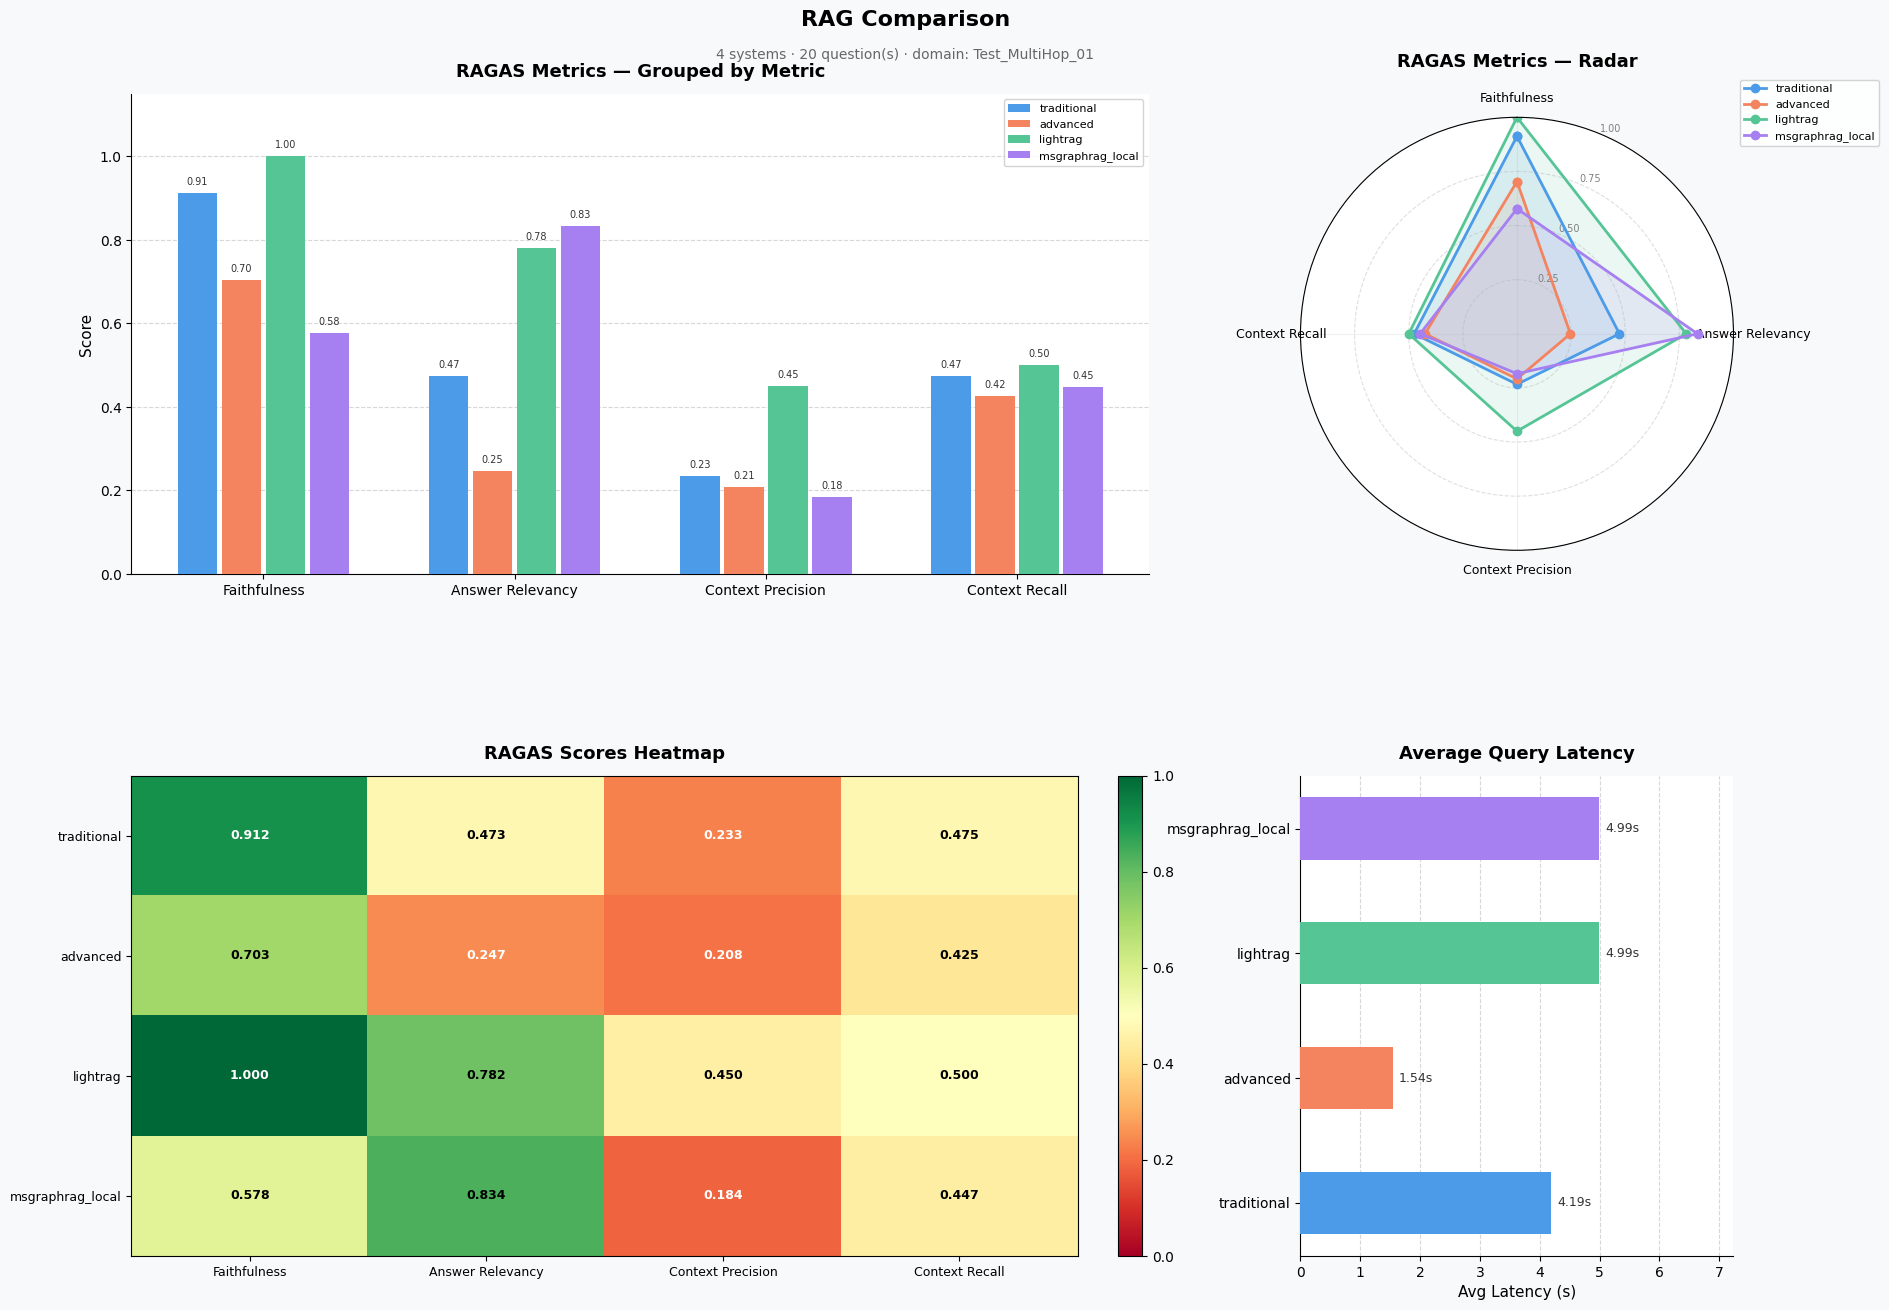

💾 Guardado en: plots/rag_comparison_comparison.png


PosixPath('plots/rag_comparison_comparison.png')

In [13]:
from src.plots.rag_visualizer import plot_rag_comparison

plot_rag_comparison(results_dir="./results", output_dir="./plots")